# Decision Trees and Random Forests

A simple classification practical using the local Day 2 housing dataset.


## my goal

Build one decision tree, read its rules, make a prediction and compare it with a random forest.


## 1. imports


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

DATA_DIR = Path("day_2/Slides-Notes/Datasets")
if not DATA_DIR.exists():
    DATA_DIR = Path("../Slides-Notes/Datasets")
sns.set_theme(style="whitegrid", context="notebook")

## 2. Load and prepare the data


In [2]:
housing = pd.read_csv(DATA_DIR / "housing.csv")
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853


The target is `1` when a district's median house value is above the dataset median, otherwise it is `0`.


In [3]:
features = ["median_income", "housing_median_age", "rooms_per_household", "latitude", "longitude"]
X = housing[features]
value_cutoff = housing["median_house_value"].median()
y = (housing["median_house_value"] > value_cutoff).astype(int)

print(f"Rows: {len(X):,}")
print(f"High-value cutoff: ${value_cutoff:,.0f}")
y.value_counts().rename(index={0: "Standard value", 1: "High value"}).to_frame("Rows")

Rows: 20,640
High-value cutoff: $179,700


,Rows
median_house_value,
Standard value,10323
High value,10317


## 3. Split the data

The test set is kept separate so the model is evaluated on unseen rows.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training rows: {len(X_train):,} | Test rows: {len(X_test):,}")

Training rows: 16,512 | Test rows: 4,128


## 4. training a decision tree

A depth of 3 keeps the model readable and reduces overfitting.


In [5]:
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=100, random_state=42)
tree.fit(X_train, y_train)

tree_predictions = tree.predict(X_test)
print(f"Decision tree accuracy: {accuracy_score(y_test, tree_predictions):.1%}")

Decision tree accuracy: 74.6%


### Confusion matrix


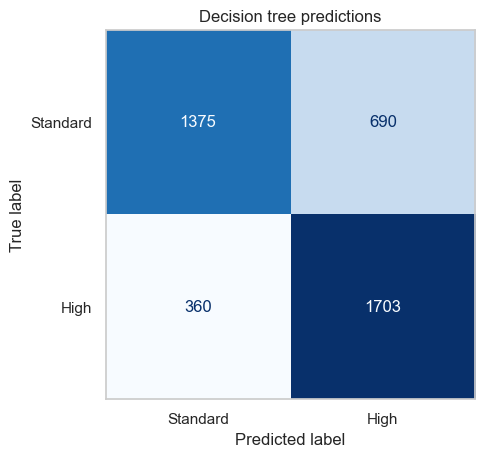

In [6]:
fig, ax = plt.subplots(figsize=(5.8, 4.8))
ConfusionMatrixDisplay.from_predictions(
    y_test, tree_predictions, display_labels=["Standard", "High"],
    cmap="Blues", colorbar=False, ax=ax
)
ax.set_title("Decision tree predictions")
plt.grid(False)
plt.show()

## 5. View the tree

Each box shows the split, number of rows and predicted class.


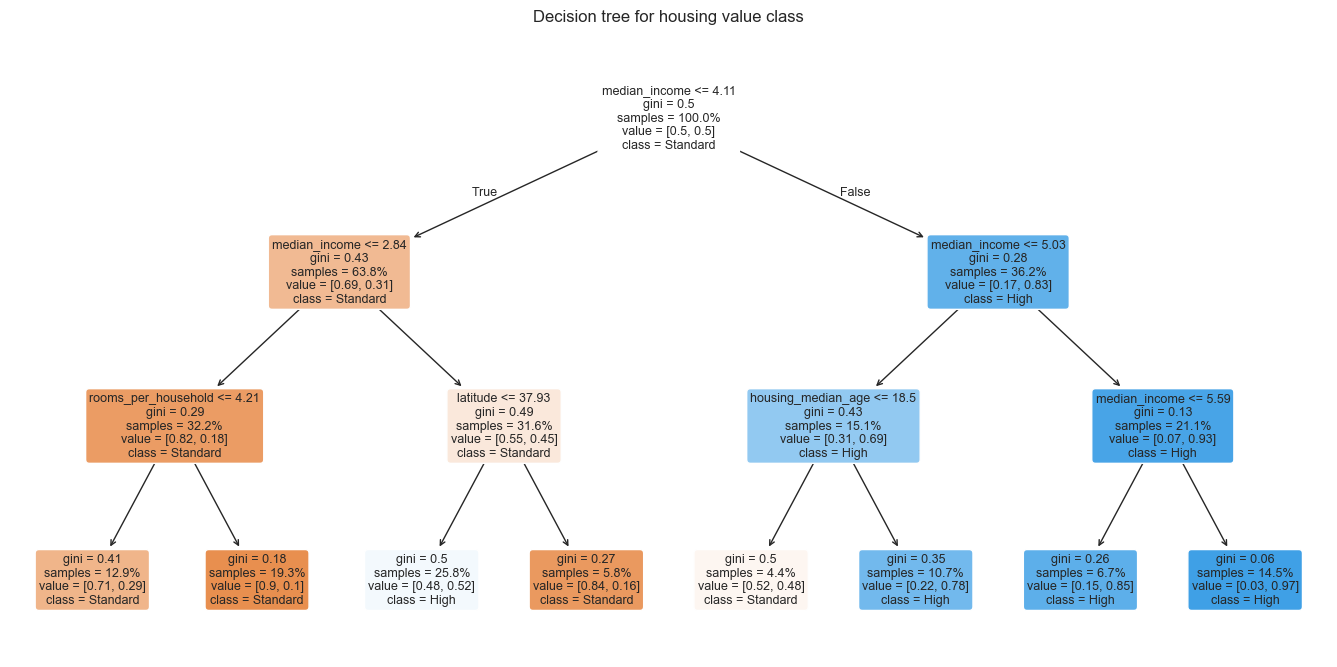

In [7]:
fig, ax = plt.subplots(figsize=(17, 8))
plot_tree(tree, feature_names=features, class_names=["Standard", "High"],
          filled=True, rounded=True, proportion=True, precision=2, fontsize=9, ax=ax)
ax.set_title("Decision tree for housing value class", pad=14)
plt.show()

## 6. Read the rules


In [8]:
print(export_text(tree, feature_names=features, decimals=2))

|--- median_income <= 4.11
|   |--- median_income <= 2.84
|   |   |--- rooms_per_household <= 4.21
|   |   |   |--- class: 0
|   |   |--- rooms_per_household >  4.21
|   |   |   |--- class: 0
|   |--- median_income >  2.84
|   |   |--- latitude <= 37.93
|   |   |   |--- class: 1
|   |   |--- latitude >  37.93
|   |   |   |--- class: 0
|--- median_income >  4.11
|   |--- median_income <= 5.03
|   |   |--- housing_median_age <= 18.50
|   |   |   |--- class: 0
|   |   |--- housing_median_age >  18.50
|   |   |   |--- class: 1
|   |--- median_income >  5.03
|   |   |--- median_income <= 5.59
|   |   |   |--- class: 1
|   |   |--- median_income >  5.59
|   |   |   |--- class: 1



## 7. Predict a new district


In [9]:
new_district = pd.DataFrame([{
    "median_income": 5.5,
    "housing_median_age": 25,
    "rooms_per_household": 6.0,
    "latitude": 34.05,
    "longitude": -118.25
}])

tree_class = tree.predict(new_district)[0]
tree_probability = tree.predict_proba(new_district)[0, 1]
print("Predicted class:", "High value" if tree_class == 1 else "Standard value")
print(f"High-value probability: {tree_probability:.1%}")

Predicted class: High value
High-value probability: 84.8%


## 8. Train a random forest

The forest combines many trees and usually gives a more stable result.


In [10]:
forest = RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_leaf=10,
                                random_state=42, n_jobs=-1)
forest.fit(X_train, y_train)
forest_predictions = forest.predict(X_test)

print(f"Decision tree accuracy: {accuracy_score(y_test, tree_predictions):.1%}")
print(f"Random forest accuracy: {accuracy_score(y_test, forest_predictions):.1%}")

Decision tree accuracy: 74.6%
Random forest accuracy: 87.3%


## 9. Feature importance


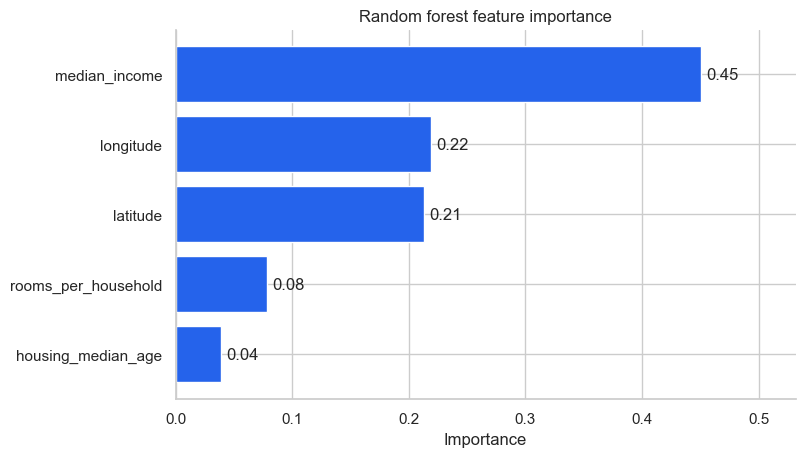

In [11]:
importance = (pd.Series(forest.feature_importances_, index=features, name="Importance")
              .sort_values())

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.barh(importance.index, importance.values, color="#2563EB")
ax.bar_label(bars, fmt="%.2f", padding=4)
ax.set(title="Random forest feature importance", xlabel="Importance", ylabel="")
ax.set_xlim(0, importance.max() * 1.18)
sns.despine()
plt.show()

## my lessons learned

- The shallow decision tree is easy to explain but cannot capture every pattern.
- The random forest combines many trees for a stronger prediction.
- Feature importance shows which measurements influenced the forest most.
